In [1]:
from pathlib import Path
from typing import Any

import numpy as np
from numpy.typing import NDArray
from tqdm import tqdm

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.images import argmax
import darksun as ds
from darksun.data import DataLoader, CatalogueLoader

import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
def check_and_pick(parent: Path, pattern: str) -> Path:
    matches = tuple(parent.glob(pattern))
    if not matches:
        raise ValueError(f"A file matching the pattern {str(parent / pattern)} is expected but missing.")
    f, *extra_matches = matches
    if extra_matches:
        raise ValueError(
            f"Found unexpected extra matches for glob pattern {str(parent / pattern)}."
            f"File with pattern {pattern} should be unique"
        )
    return f

In [3]:
# dirpath: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
dirpath: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

MASK_FITS: str = f"{dirpath}/mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 10, 1

SKYFIELD: str = "CameraGeometry"
basepath: str = f"{dirpath}/{SKYFIELD}"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 50.0           # [keV]

In [4]:
wfm: CodedMaskCamera = codedmask(MASK_FITS, UPS_X, UPS_Y)
sdl: DataLoader = ds.get_data(
    check_and_pick(Path(f'{basepath}/baseline/baseline'), f'{ID_CAMERA_A}/*{DATASET}*.fits'),
    E_min=E_min,
    E_max=E_max,
)
sdl_100um: DataLoader = ds.get_data(
    check_and_pick(Path(f'{basepath}/sdd_plane_contrapts/sdd_plane_radial_contr/radial_contr_100um'), f'{ID_CAMERA_A}/*{DATASET}*.fits'),
    E_min=E_min,
    E_max=E_max,
)

In [5]:
def raw_count(camera: CodedMaskCamera, data: NDArray) -> NDArray:
    """Create 2D histogram of detector counts from event data."""
    bins = camera.bins_detector
    hist, *_ = np.histogram2d(data["Y"], data["X"], bins=[bins.y, bins.x])
    return hist

In [8]:
det, det100um = map(lambda x: count(wfm, x)[0], (sdl.DLdata, sdl_100um.DLdata))
raw_det, raw_det100um = map(lambda x: raw_count(wfm, x), (sdl.DLdata, sdl_100um.DLdata))

In [9]:
tuple(map(np.sum, (det, det100um, det100um * (wfm.bulk > 0)))), tuple(map(np.sum, (raw_det, raw_det100um, raw_det100um * (wfm.bulk > 0))))

((np.float64(1372938.0), np.float64(1371703.0), np.float64(1371703.0)),
 (np.float64(1379773.0), np.float64(1381429.0), np.float64(1371703.0)))

In [12]:
1372938.0 - 1371703.0

1235.0

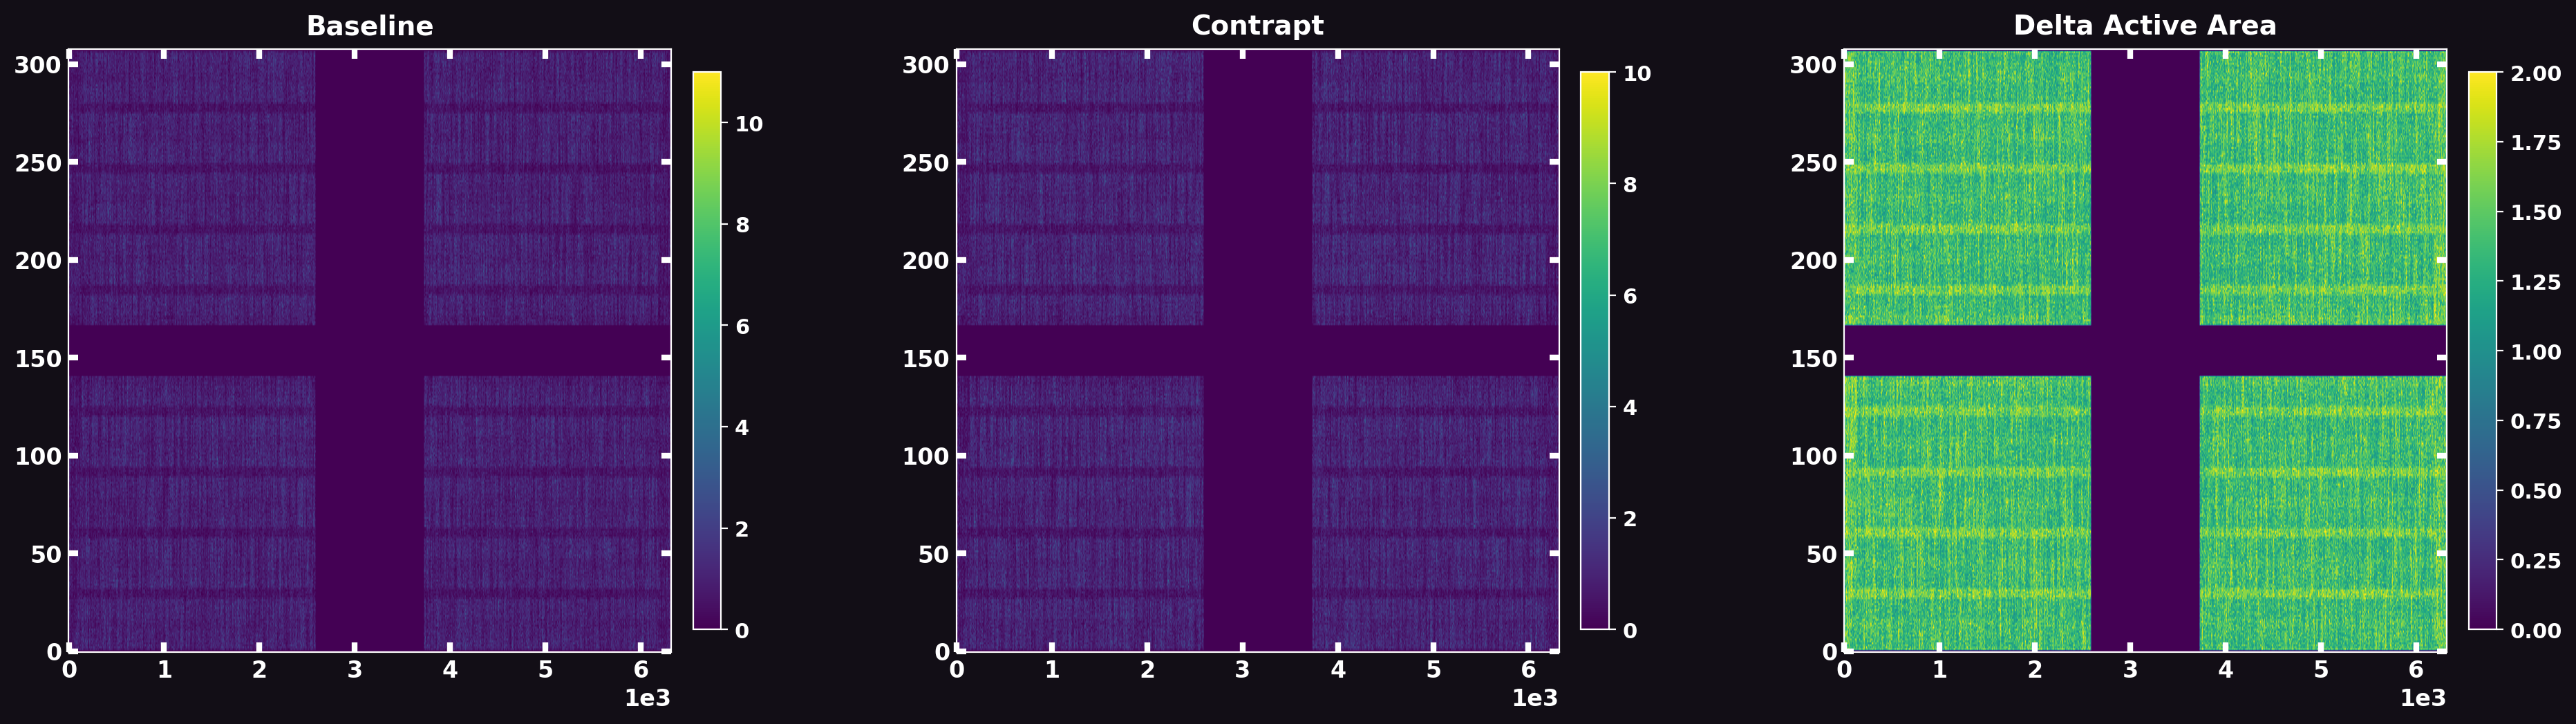

In [7]:
active_area_diff = 2 * np.ones_like(det) * (wfm.bulk > 0) - np.ones_like(det100um) * (det100um > 0)

kws = {
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
}

ds.image_plot(
    dmaps=(
        ds.map4image(det, title='Baseline', img_kwargs=kws),
        ds.map4image(det100um, title='Contrapt', img_kwargs=kws),
        ds.map4image(active_area_diff, title='Delta Active Area', img_kwargs=kws),
    ),
    ncols=3,
)

In [9]:
from pathlib import Path

simspath: str = 'root'

paths = [
    f'{simspath}/mask_rots/mask_Zrot/Zrot_-0.5arcmin',
    f'{simspath}/mask_rots/mask_Zrot/Zrot_1arcmin',
    f'{simspath}/mask_rots/mask_Zrot/Zrot_2arcmin',
    f'{simspath}/mask_rots/mask_Zrot/Zrot_4arcmin',
    f'{simspath}/mask_rots/mask_Zrot/Zrot_6arcmin',
]
paths_ = tuple(map(Path, paths))

for p in paths_:
    print(
        f'{-1 * float(str(p.name)[5 : -6]) / 60}'
    )

0.008333333333333333
-0.016666666666666666
-0.03333333333333333
-0.06666666666666667
-0.1
